# Imports

In [152]:
import json
import os
import pickle
from collections import Counter
from datetime import datetime

import numpy as np
import optuna
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold

from beatmap_classifier.classifier.augment_faster import (
    augment_dataset,
    extract_movement_features_from_X,
)
from beatmap_classifier.classifier.cnn_model import CNNModel
from beatmap_classifier.classifier.utils_training import (
    get_additional_features,
    get_data,
    load_pytorch_models,
    pad_sequences_pt,
    plot_training_history,
    train_and_evaluate,
)

# Model Testing

Go run test_model.py

# Initializing some Data

In [56]:
TOURNAMENT_MODS = {
    "nm1": "NM",
    "nm2": "NM",
    "nm3": "NM",
    "nm4": "NM",
    "nm5": "NM",
    "nm6": "NM",
    "hd1": "HD",
    "hd2": "HD",
    "hd3": "HD",
    "hr1": "HR",
    "hr2": "HR",
    "hr3": "HR",
    "dt1": "DT",
    "dt2_and_dt3": "DT",
    "dt4": "DT",
    "tiebreaker": "NM",
}

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

db_path = 'beatmaps.db'

X, y, beatmap_ids = get_data(db_path)
raw_additional_features, normalized_additional_features = get_additional_features(db_path, y, beatmap_ids)

Max Vector Length: 500.0
Max Time Diff: 86087.0
Tournament-labeled beatmaps: 3922
Max Vector Count: 6309
Original beatmaps: 3922


In [58]:
# Get the mod associated with each tournament label
mods_flattened = [
    TOURNAMENT_MODS[label]
    if TOURNAMENT_MODS[label]
    else "NM"
    for label in y
]

raw_additional_features_array = np.array([
    raw_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

normalized_additional_features_array = np.array([
    normalized_additional_features[(beatmap_id, mod)]
    for beatmap_id, mod in zip(beatmap_ids, mods_flattened)
])

In [59]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    beatmap_ids_train,
    beatmap_ids_test,
) = train_test_split(
    X,
    y,
    beatmap_ids,
    test_size=0.2,
    random_state=42,
)

print(f"Final train size: {len(X_train)}")
print(f"Final test size:  {len(X_test)}")

Final train size: 3137
Final test size:  785


In [60]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(y)

with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

y_train_numerical = label_encoder.transform(y_train)
y_test_numerical = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

y_train_numerical = torch.tensor(y_train_numerical, dtype=torch.long)
y_test_numerical = torch.tensor(y_test_numerical, dtype=torch.long)

# Pad sequences
sequence_lengths = np.array([len(seq) for seq in X])
max_length = int(np.percentile(sequence_lengths, 99))
max_length = 2 ** int(np.ceil(np.log2(max_length)))
max_length = min(max_length, 4096)

print(f"Using max sequence length: {max_length}")

X_train = pad_sequences_pt(
    X_train,
    maxlen=max_length,
    dtype=torch.float32
)

X_test = pad_sequences_pt(
    X_test,
    maxlen=max_length,
    dtype=torch.float32
)

print("Before metadata:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Using max sequence length: 4096
Before metadata:
X_train: torch.Size([3137, 4096, 8])
X_test:  torch.Size([785, 4096, 8])


In [61]:
class_counts = Counter(y_train_numerical.numpy())

for cls, count in sorted(class_counts.items()):
    print(f"Class {cls}: {count}")

print(dict(enumerate(label_encoder.classes_)))

Class 0: 703
Class 1: 710
Class 2: 731
Class 3: 608
Class 4: 385
{0: np.str_('nm1'), 1: np.str_('nm2'), 2: np.str_('nm3'), 3: np.str_('nm4'), 4: np.str_('nm5')}


In [62]:
# Extract geometric summary vectors for each row in X_train and X_test
movement_features_train = np.array(
    [extract_movement_features_from_X(X_train[i]) for i in range(len(X_train))],
    dtype=np.float32,
)

movement_features_test = np.array(
    [extract_movement_features_from_X(X_test[i]) for i in range(len(X_test))],
    dtype=np.float32,
)

# NOTICE THAT WE SWITCH FROM NORMALIZED TO RAW ADDITIONAL FEATURES
# BECAUSE XGBOOST DOESN'T NEED SCALING

# Extract SQLite metadata features corresponding to train/test IDs
mods_flattened_train = [
    TOURNAMENT_MODS.get(label, "NM")
    for label in y_train
]

sql_features_train = np.array(
    [
        raw_additional_features[(b_id, mod)]
        for b_id, mod in zip(beatmap_ids_train, mods_flattened_train)
    ],
    dtype=np.float32,
)

mods_flattened_test = [
    TOURNAMENT_MODS.get(label, "NM")
    for label in y_test
]

sql_features_test = np.array(
    [
        raw_additional_features.get((b_id, mod))
        for b_id, mod in zip(beatmap_ids_test, mods_flattened_test)
    ],
    dtype=np.float32,
)

# Concatenate (SQL metadata + Movement geometric summary)
X_additional_train = np.hstack(
    [sql_features_train, movement_features_train]
)
X_additional_test = np.hstack(
    [sql_features_test, movement_features_test]
)

print(f"Full meta tabular train shape: {X_additional_train.shape}")
print(f"Full meta tabular test shape:  {X_additional_test.shape}")

Full meta tabular train shape: (3137, 24)
Full meta tabular test shape:  (785, 24)


# CNN Model (SKIP TO XGBOOST IF DESIRED)

--- Training Meta Fold 1/5 ---
Original samples: 2509 -> Augmented total: 10036
Epoch 1/50 - loss: 2.3757 - acc: 0.3784 - val_loss: 1.2251 - val_acc: 0.5764
Epoch 2/50 - loss: 1.3277 - acc: 0.4885 - val_loss: 1.1412 - val_acc: 0.6369
Epoch 3/50 - loss: 1.2450 - acc: 0.5489 - val_loss: 1.0046 - val_acc: 0.7150
Epoch 4/50 - loss: 1.1870 - acc: 0.5920 - val_loss: 0.9987 - val_acc: 0.7229
Epoch 5/50 - loss: 1.1289 - acc: 0.6236 - val_loss: 0.9537 - val_acc: 0.7229
Epoch 6/50 - loss: 1.1052 - acc: 0.6287 - val_loss: 0.9346 - val_acc: 0.7277
Epoch 7/50 - loss: 1.0904 - acc: 0.6314 - val_loss: 0.9398 - val_acc: 0.7325
Epoch 8/50 - loss: 1.0579 - acc: 0.6648 - val_loss: 0.8980 - val_acc: 0.7532
Epoch 9/50 - loss: 1.0368 - acc: 0.6657 - val_loss: 0.9028 - val_acc: 0.7452
Epoch 10/50 - loss: 1.0132 - acc: 0.6781 - val_loss: 0.8700 - val_acc: 0.7643
Epoch 11/50 - loss: 0.9975 - acc: 0.6939 - val_loss: 0.8557 - val_acc: 0.7882
Epoch 12/50 - loss: 0.9763 - acc: 0.7144 - val_loss: 0.8487 - val_acc: 

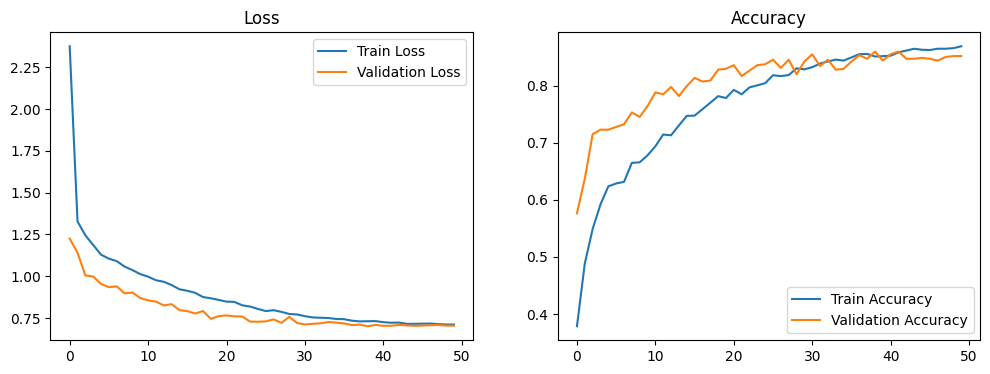

--- Training Meta Fold 2/5 ---
Original samples: 2509 -> Augmented total: 10036
Epoch 1/50 - loss: 2.6391 - acc: 0.3874 - val_loss: 1.2017 - val_acc: 0.6258
Epoch 2/50 - loss: 1.2711 - acc: 0.5181 - val_loss: 1.0888 - val_acc: 0.6752
Epoch 3/50 - loss: 1.1976 - acc: 0.5592 - val_loss: 1.0673 - val_acc: 0.6736
Epoch 4/50 - loss: 1.1460 - acc: 0.6083 - val_loss: 1.0092 - val_acc: 0.7150
Epoch 5/50 - loss: 1.1093 - acc: 0.6267 - val_loss: 0.9908 - val_acc: 0.7213
Epoch 6/50 - loss: 1.0937 - acc: 0.6325 - val_loss: 0.9527 - val_acc: 0.7420
Epoch 7/50 - loss: 1.0637 - acc: 0.6507 - val_loss: 0.9539 - val_acc: 0.7436
Epoch 8/50 - loss: 1.0629 - acc: 0.6543 - val_loss: 0.9426 - val_acc: 0.7500
Epoch 9/50 - loss: 1.0413 - acc: 0.6656 - val_loss: 0.9859 - val_acc: 0.7086
Epoch 10/50 - loss: 1.0306 - acc: 0.6776 - val_loss: 0.9088 - val_acc: 0.7818
Epoch 11/50 - loss: 1.0084 - acc: 0.6896 - val_loss: 0.9040 - val_acc: 0.7564
Epoch 12/50 - loss: 0.9829 - acc: 0.7056 - val_loss: 0.8788 - val_acc: 

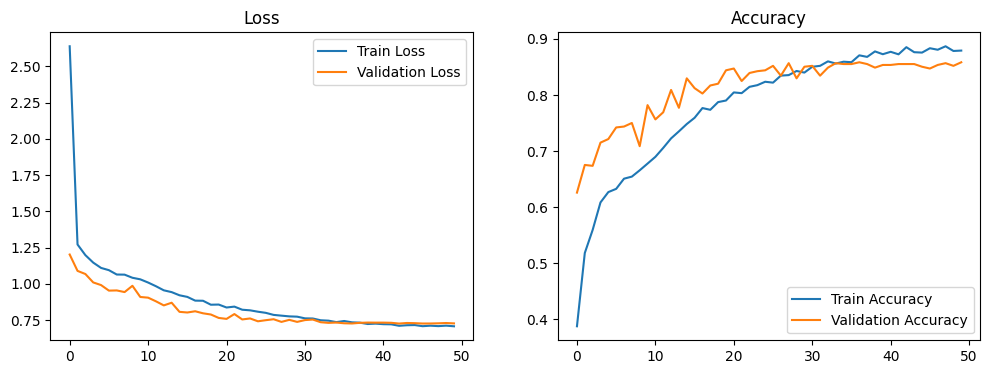

--- Training Meta Fold 3/5 ---
Original samples: 2510 -> Augmented total: 10040
Epoch 1/50 - loss: 2.3158 - acc: 0.3874 - val_loss: 1.2715 - val_acc: 0.6124
Epoch 2/50 - loss: 1.3206 - acc: 0.4990 - val_loss: 1.1200 - val_acc: 0.6108
Epoch 3/50 - loss: 1.2315 - acc: 0.5594 - val_loss: 1.0430 - val_acc: 0.6986
Epoch 4/50 - loss: 1.1682 - acc: 0.6035 - val_loss: 1.0020 - val_acc: 0.7065
Epoch 5/50 - loss: 1.1316 - acc: 0.6182 - val_loss: 0.9859 - val_acc: 0.7177
Epoch 6/50 - loss: 1.1027 - acc: 0.6430 - val_loss: 0.9739 - val_acc: 0.7081
Epoch 7/50 - loss: 1.0838 - acc: 0.6555 - val_loss: 0.9582 - val_acc: 0.7289
Epoch 8/50 - loss: 1.0549 - acc: 0.6771 - val_loss: 0.9537 - val_acc: 0.7384
Epoch 9/50 - loss: 1.0274 - acc: 0.6877 - val_loss: 0.9072 - val_acc: 0.7656
Epoch 10/50 - loss: 1.0266 - acc: 0.6885 - val_loss: 0.9124 - val_acc: 0.7448
Epoch 11/50 - loss: 1.0046 - acc: 0.7031 - val_loss: 0.8833 - val_acc: 0.7528
Epoch 12/50 - loss: 0.9710 - acc: 0.7268 - val_loss: 0.8695 - val_acc: 

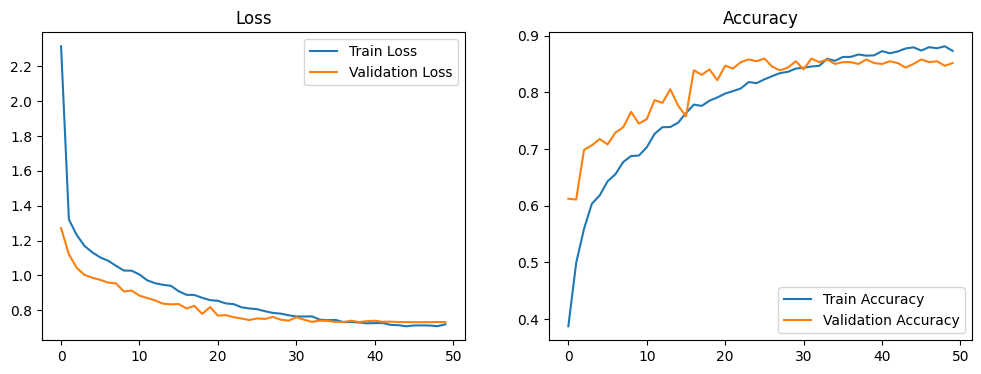

--- Training Meta Fold 4/5 ---
Original samples: 2510 -> Augmented total: 10040
Epoch 1/50 - loss: 2.7987 - acc: 0.4121 - val_loss: 1.2445 - val_acc: 0.6029
Epoch 2/50 - loss: 1.3070 - acc: 0.5403 - val_loss: 1.1512 - val_acc: 0.6364
Epoch 3/50 - loss: 1.2421 - acc: 0.5663 - val_loss: 1.0789 - val_acc: 0.6762
Epoch 4/50 - loss: 1.1918 - acc: 0.5880 - val_loss: 1.0425 - val_acc: 0.6842
Epoch 5/50 - loss: 1.1613 - acc: 0.6085 - val_loss: 1.0132 - val_acc: 0.6826
Epoch 6/50 - loss: 1.1159 - acc: 0.6383 - val_loss: 0.9814 - val_acc: 0.6986
Epoch 7/50 - loss: 1.0837 - acc: 0.6546 - val_loss: 0.9568 - val_acc: 0.7257
Epoch 8/50 - loss: 1.0651 - acc: 0.6538 - val_loss: 0.9444 - val_acc: 0.7289
Epoch 9/50 - loss: 1.0497 - acc: 0.6659 - val_loss: 0.9368 - val_acc: 0.7289
Epoch 10/50 - loss: 1.0356 - acc: 0.6811 - val_loss: 0.9309 - val_acc: 0.7352
Epoch 11/50 - loss: 1.0248 - acc: 0.6829 - val_loss: 0.9266 - val_acc: 0.7432
Epoch 12/50 - loss: 1.0099 - acc: 0.6875 - val_loss: 0.9190 - val_acc: 

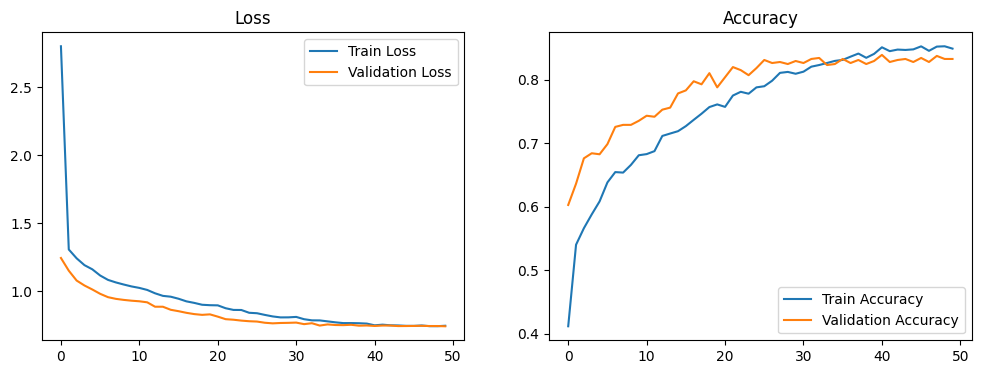

--- Training Meta Fold 5/5 ---
Original samples: 2510 -> Augmented total: 10040
Epoch 1/50 - loss: 2.2681 - acc: 0.4077 - val_loss: 1.2248 - val_acc: 0.5359
Epoch 2/50 - loss: 1.2511 - acc: 0.5371 - val_loss: 1.0805 - val_acc: 0.6651
Epoch 3/50 - loss: 1.1750 - acc: 0.5873 - val_loss: 0.9852 - val_acc: 0.7432
Epoch 4/50 - loss: 1.1264 - acc: 0.6188 - val_loss: 0.9827 - val_acc: 0.7337
Epoch 5/50 - loss: 1.0967 - acc: 0.6374 - val_loss: 0.9601 - val_acc: 0.7480
Epoch 6/50 - loss: 1.0863 - acc: 0.6371 - val_loss: 0.9224 - val_acc: 0.7687
Epoch 7/50 - loss: 1.0513 - acc: 0.6652 - val_loss: 0.9232 - val_acc: 0.7656
Epoch 8/50 - loss: 1.0339 - acc: 0.6727 - val_loss: 0.8935 - val_acc: 0.7831
Epoch 9/50 - loss: 1.0262 - acc: 0.6794 - val_loss: 0.9063 - val_acc: 0.7735
Epoch 10/50 - loss: 1.0150 - acc: 0.6859 - val_loss: 0.8906 - val_acc: 0.7879
Epoch 11/50 - loss: 1.0020 - acc: 0.6902 - val_loss: 0.8852 - val_acc: 0.7879
Epoch 12/50 - loss: 0.9981 - acc: 0.6925 - val_loss: 0.8860 - val_acc: 

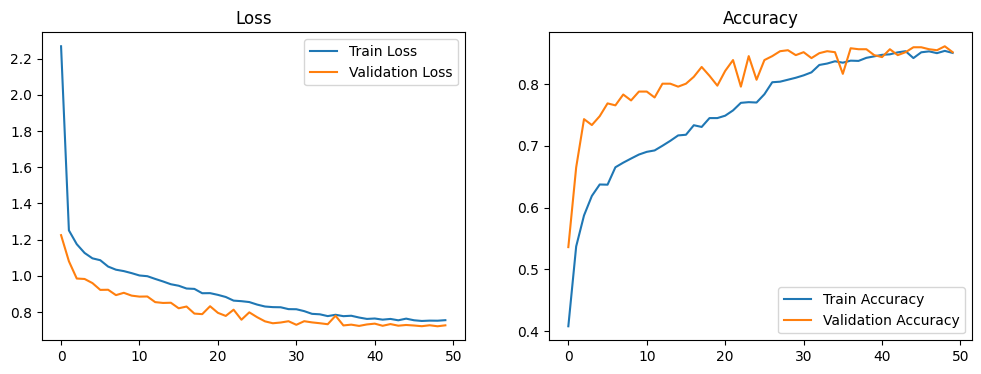

In [66]:
meta_bagging_models = []
beatmap_ids_train = np.array(beatmap_ids_train)

# Initialize empty matrix for clean Out-Of-Fold CNN probability predictions
oof_cnn_predictions = np.zeros((len(X_train), num_classes), dtype=np.float32)

# Use GroupKFold so mapset difficulties stay grouped
gkf = GroupKFold(n_splits=5)

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train_numerical, groups=beatmap_ids_train)):
    print(f"--- Training Meta Fold {fold + 1}/5 ---")

    # Split raw unaugmented fold data
    X_fold_train, y_fold_train = X_train[train_idx], y_train_numerical[train_idx]
    X_fold_val, y_fold_val = X_train[val_idx], y_train_numerical[val_idx]
    beatmap_ids_fold_train = beatmap_ids_train[train_idx]

    # Augment ONLY the training fold
    X_fold_train_aug, y_fold_train_aug, _ = augment_dataset(
        X_fold_train,
        y_fold_train,
        beatmap_ids_fold_train,
        augmentation_types={"horizontal", "vertical", "horizontal_vertical"}
    )

    # Convert validation fold to PyTorch Tensor (permuted to (B, C, L))
    X_fold_val = torch.as_tensor(X_fold_val, dtype=torch.float32).permute(0, 2, 1)
    y_fold_val = torch.as_tensor(y_fold_val, dtype=torch.long)

    X_fold_train_aug = X_fold_train_aug.permute(0, 2, 1)

    # Train CNN model for this fold
    model, history = train_and_evaluate(
        X_fold_train_aug,
        y_fold_train_aug,
        X_fold_val,
        y_fold_val,
        input_channels=X_fold_train_aug.shape[1],
        num_classes=num_classes,
        max_length=max_length,
        learning_rate=0.001,
        dropout_rate=0.5, # old: 0.5
        l2_reg=0.001,
        batch_size=128,
        epochs=50, # old: 30
        patience=15
    )
    plot_training_history(history)
    meta_bagging_models.append(model)

    # Generate Out-of-Fold predictions for the unaugmented validation set ONLY
    model.eval()
    with torch.no_grad():
        val_inputs = X_fold_val.to(device)
        logits = model(val_inputs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

    # Store clean OOF predictions in the array
    oof_cnn_predictions[val_idx] = probs

In [67]:
os.makedirs('models/bagged_models', exist_ok=True)

for i, model in enumerate(meta_bagging_models):
    torch.save(model.state_dict(), f'models/bagged_models/bagged_cnn_model_{i}.pth')

np.save("models/oof_cnn_predictions.npy", oof_cnn_predictions)
np.save("models/y_train_numerical.npy", y_train_numerical)
np.save("models/beatmap_ids_train.npy", np.array(beatmap_ids_train))

# XGBoost Meta Model

### Load Models and Data

In [119]:
model_kwargs = {
    "input_channels": 8,
    "num_classes": num_classes,
    "max_length": max_length,
    "dropout_rate": 0.5,
}

meta_bagging_models = load_pytorch_models(
    model_folder="models/bagged_models",
    model_class=CNNModel,
    model_kwargs=model_kwargs,
    device=device,
)

oof_cnn_predictions = np.load("models/oof_cnn_predictions.npy")
y_train_numerical = np.load("models/y_train_numerical.npy")

print(f"Loaded {len(meta_bagging_models)} CNN models")

Loaded 5 CNN models


### Test the bagging models
87% is already pretty good, but we will see soon that we can improve it

In [120]:
# Generate Test probabilities by averaging predictions across all fold models
X_test_tensor = torch.as_tensor(X_test, dtype=torch.float32).permute(0, 2, 1).to(device)
test_probs_list = []

for model in meta_bagging_models:
    model.eval()
    with torch.no_grad():
        logits = model(X_test_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        test_probs_list.append(probs)

bagged_test_predictions = np.mean(test_probs_list, axis=0)
bagged_test_predictions_numerical = np.argmax(bagged_test_predictions, axis=1)

score = accuracy_score(y_test_numerical, bagged_test_predictions_numerical)
cm = confusion_matrix(y_test_numerical, bagged_test_predictions_numerical)
report = classification_report(
    y_test_numerical,
    bagged_test_predictions_numerical,
    zero_division=0,
    target_names=["NM1", "NM2", "NM3", "NM4", "NM5"] # "DT1", "DT2_and_DT3", "HD2", "HR1", "HR2",
)

print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)
print(f"Accuracy: {score}")

Classification Report:
               precision    recall  f1-score   support

         NM1       0.94      0.94      0.94       192
         NM2       0.88      0.92      0.90       158
         NM3       0.84      0.86      0.85       186
         NM4       0.84      0.81      0.82       153
         NM5       0.84      0.78      0.81        96

    accuracy                           0.87       785
   macro avg       0.87      0.86      0.86       785
weighted avg       0.87      0.87      0.87       785

Confusion Matrix:
 [[180   0   8   3   1]
 [  0 146   2   0  10]
 [  6   2 160  17   1]
 [  3   5  19 124   2]
 [  2  13   2   4  75]]
Accuracy: 0.8726114649681529


### Setup

Make sure that this setup matches in `/beatmap_recommender/recommender_db_setup/precompute_nm1-5.py` whenever you're done.

In [121]:
sql_feature_names = [
    "ar",
    "od",
    "circle_size",
    "star_rating",
    "bpm",
    "max_combo",
    "length_seconds",
    "object_count",
    "pp",
    "pp_aim",
    "pp_speed",
    "pp_acc"
]

movement_feature_names = [
    "slider_ratio",
    "slider_length_std",
    "speed_std",
    "speed_change_std",
    "speed_change_max",
    "angle_std",
    "angle_mean",
    "rhythm_variance",
    "distance_mean",
    "speed_change_95th",
    "angle_90th",
    "sharp_turn_ratio",
]

cnn_feature_names = [
    "CNN_NM1",
    "CNN_NM2",
    "CNN_NM3",
    "CNN_NM4",
    "CNN_NM5",
]

additional_feature_names = (
    sql_feature_names +
    movement_feature_names
)

In [122]:
print(additional_feature_names)

['ar', 'od', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'object_count', 'pp', 'pp_aim', 'pp_speed', 'pp_acc', 'slider_ratio', 'slider_length_std', 'speed_std', 'speed_change_std', 'speed_change_max', 'angle_std', 'angle_mean', 'rhythm_variance', 'distance_mean', 'speed_change_95th', 'angle_90th', 'sharp_turn_ratio']


You can add more feature groups here, if desired

In [219]:
# GROUP 1
excluded_features = {
    "pp_speed",
    "distance_mean",
    "object_count",
    "speed_change_std",
    "angle_90th",
    "od",
    "speed_change_max"
}

group1_features = [
    feature
    for feature in additional_feature_names
    if feature not in excluded_features
]

# GROUP 2
# excluded_features = {
#     "speed_change_95th",
# }
#
# group2_features = [
#     feature
#     for feature in additional_feature_names
#     if feature not in excluded_features
# ]
#

# COMBINE ALL GROUPS TOGETHER
additional_feature_groups = {
    "group1": group1_features,
    # "group2": group2_features,
}

feature_indices = {
    group_name: [
        additional_feature_names.index(feature)
        for feature in features
    ]
    for group_name, features in additional_feature_groups.items()
}

In [220]:
def make_xgb(params):
    return XGBClassifier(
        random_state=42,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        **params
    )

def optimize_xgb_feature_set(
    X_additional_train,
    oof_cnn_predictions,
    y_train,
    indices,
    n_trials=50,
    seed=42,
):
    X_meta_train = np.hstack([
        oof_cnn_predictions,
        X_additional_train[:, indices],
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed,
    )

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 250, 750, step=50),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 1.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        }

        scores = []

        for train_idx, valid_idx in cv.split(X_meta_train, y_train):
            X_train = X_meta_train[train_idx]
            X_valid = X_meta_train[valid_idx]

            y_train_fold = y_train[train_idx]
            y_valid_fold = y_train[valid_idx]

            model = make_xgb(params)
            model.fit(X_train, y_train_fold, eval_set=[(X_valid, y_valid_fold)], verbose=False)
            pred = model.predict(X_valid)

            scores.append(f1_score(y_valid_fold, pred, average="macro", zero_division=0))

        return np.mean(scores)

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study

def evaluate_feature_set(
    selected_features,
    X_additional_train,
    X_additional_test,
    oof_cnn_predictions,
    bagged_test_predictions,
    y_train,
    y_test,
    params,
    compare_feature_groups,
    indices
):

    if not compare_feature_groups:
        indices = [
            additional_feature_names.index(name)
            for name in selected_features
        ]

    X_meta_train = np.hstack([
        oof_cnn_predictions,
        X_additional_train[:, indices],
    ])

    X_meta_test = np.hstack([
        bagged_test_predictions,
        X_additional_test[:, indices],
    ])

    model = make_xgb(params)
    model.fit(X_meta_train, y_train)

    pred = model.predict(X_meta_test)

    acc = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    cm = confusion_matrix(y_test, pred)

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "nm3_to_nm4": cm[2, 3],
        "nm4_to_nm3": cm[3, 2],
    }, model, pred

In [221]:
def get_feature_indices(feature_names, selected_features):
    missing = [
        name
        for name in selected_features
        if name not in feature_names
    ]

    if missing:
        raise ValueError(f"Features not found: {missing}")

    return [
        feature_names.index(name)
        for name in selected_features
    ]

### Compare the XGBoost Classifiers within Feature Groups

Skip this cell if you're trying to compared changed features, and already obtained some good params in `./models/xgb_best_params.json`

Change n_trials if needed.

In [172]:
studies = {}
best_params = {}

for group_name, indices in feature_indices.items():
    study = optimize_xgb_feature_set(
        X_additional_train=X_additional_train,
        oof_cnn_predictions=oof_cnn_predictions,
        y_train=y_train_numerical,
        indices=indices,
        n_trials=100,
    )

    studies[group_name] = study

    best_params[group_name] = {
        "macro_f1": study.best_value,
        "params": study.best_params,
    }

    print(f"\nBest macro F1: {study.best_value:.4f}")
    print("Best parameters:")

    for param, value in study.best_params.items():
        print(f"  {param}: {value}")

# Save this entire experiment as a new file
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = f"models/xgb_params/xgb_best_params_{timestamp}.json"

with open(output_path, "w") as f:
    json.dump(best_params, f, indent=4)

print(f"\nSaved best parameters to: {output_path}")

[I 2026-09-17 15:41:45,052] A new study created in memory with name: no-name-44b16ada-b85e-431e-9dda-db81770150cf


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-09-17 15:41:48,591] Trial 0 finished with value: 0.9150601116847378 and parameters: {'n_estimators': 450, 'learning_rate': 0.0862735828664018, 'max_depth': 7, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0001707396743152812, 'reg_lambda': 5.3994844097874335}. Best is trial 0 with value: 0.9150601116847378.
[I 2026-09-17 15:41:50,909] Trial 1 finished with value: 0.9175025479690252 and parameters: {'n_estimators': 550, 'learning_rate': 0.04170553216181044, 'max_depth': 2, 'min_child_weight': 10, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.000533703276260396, 'reg_lambda': 0.2327067708383781}. Best is trial 1 with value: 0.9175025479690252.
[I 2026-09-17 15:41:54,407] Trial 2 finished with value: 0.9188498801837467 and parameters: {'n_estimators': 400, 'learning_rate': 0.02408207265453543, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.8447411578889518, 'colsample_b

### Compare the XGBoost Classifiers by removing single features in a Feature Group
NOTE: value maximized in previous cell is Macro F1 Score, the next cells are related to the test accuracy.

We're gonna load the best params here.

In [222]:
JSON_FILE = "xgb_best_params_20260917_154645.json"

with open(f"models/xgb_params/{JSON_FILE}", "r") as f:
    best_params = json.load(f)

best_params

{'group1': {'macro_f1': 0.9223323964658752,
  'params': {'n_estimators': 400,
   'learning_rate': 0.04650151618518967,
   'max_depth': 2,
   'min_child_weight': 2,
   'subsample': 0.8960130383835756,
   'colsample_bytree': 0.7173216448865419,
   'reg_alpha': 0.03559577486424498,
   'reg_lambda': 0.41416527190650504}}}

In [223]:
for group_name, indices in feature_indices.items():
    params = best_params[group_name]["params"]

    print("=" * 80)
    print(f"FEATURE GROUP: {group_name}")
    print(f"Number of features: {len(indices)}")
    print(f"Features:")
    print([
        additional_feature_names[i]
        for i in indices
    ])

    results, model, pred = evaluate_feature_set(
        selected_features=None,
        X_additional_train=X_additional_train,
        X_additional_test=X_additional_test,
        oof_cnn_predictions=oof_cnn_predictions,
        bagged_test_predictions=bagged_test_predictions,
        y_train=y_train_numerical,
        y_test=y_test_numerical,
        params=params,
        compare_feature_groups=True,
        indices=indices,
    )

    print(
        f"accuracy={results['accuracy'] * 100:.2f}% | "
        f"macro_f1={results['macro_f1']:.4f}"
    )

FEATURE GROUP: group1
Number of features: 17
Features:
['ar', 'circle_size', 'star_rating', 'bpm', 'max_combo', 'length_seconds', 'pp', 'pp_aim', 'pp_acc', 'slider_ratio', 'slider_length_std', 'speed_std', 'angle_std', 'angle_mean', 'rhythm_variance', 'speed_change_95th', 'sharp_turn_ratio']
accuracy=94.90% | macro_f1=0.9463


Set the desired group from the JSON in `FEATURE_GROUP`.

You might want to go back and forth, iteratively removing features from the selected group after seeing this cell's results. Keep doing this until accuracy is maximized.

The meta model is saved here.

In [230]:
FEATURE_GROUP = "group1"

params = best_params[FEATURE_GROUP]["params"]
all_features = additional_feature_groups[FEATURE_GROUP]
indices = get_feature_indices(
    additional_feature_names,
    all_features
)

# --------------------------------------------------------------
# Baseline
# --------------------------------------------------------------
baseline, meta_model, y_pred_meta = evaluate_feature_set(
    selected_features=all_features,
    X_additional_train=X_additional_train,
    X_additional_test=X_additional_test,
    oof_cnn_predictions=oof_cnn_predictions,
    bagged_test_predictions=bagged_test_predictions,
    y_train=y_train_numerical,
    y_test=y_test_numerical,
    params=params,
    compare_feature_groups=False,
    indices=None
)

with open("models/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)

print("Baseline:")
print(baseline)

baseline_acc = baseline["accuracy"]
baseline_f1 = baseline["macro_f1"]

# --------------------------------------------------------------
# Leave-one-feature-out evaluation
# --------------------------------------------------------------
array_results = []

for removed_feature in all_features:

    remaining_features = [
        feature
        for feature in all_features
        if feature != removed_feature
    ]

    remaining_indices = get_feature_indices(
        additional_feature_names,
        remaining_features
    )

    results, _, _ = evaluate_feature_set(
        selected_features=remaining_features,
        X_additional_train=X_additional_train,
        X_additional_test=X_additional_test,
        oof_cnn_predictions=oof_cnn_predictions,
        bagged_test_predictions=bagged_test_predictions,
        y_train=y_train_numerical,
        y_test=y_test_numerical,
        params=params,
        compare_feature_groups=False,
        indices=None
    )

    dict_results = {
        "removed": removed_feature,
        "accuracy": results["accuracy"],
        "macro_f1": results["macro_f1"],
        "acc_delta": results["accuracy"] - baseline_acc,
        "f1_delta": results["macro_f1"] - baseline_f1,
        "nm3_to_nm4": results["nm3_to_nm4"],
        "nm4_to_nm3": results["nm4_to_nm3"]
    }

    array_results.append(dict_results)

results_df = pd.DataFrame(array_results)

results_df = results_df.sort_values(
    "acc_delta",
    ascending=False
)

print(results_df.to_string(index=False))
print("=" * 100)

Baseline:
{'accuracy': 0.9490445859872612, 'macro_f1': 0.9462732478725538, 'nm3_to_nm4': np.int64(6), 'nm4_to_nm3': np.int64(5)}
          removed  accuracy  macro_f1  acc_delta  f1_delta  nm3_to_nm4  nm4_to_nm3
           pp_aim  0.946497  0.943390  -0.002548 -0.002884           7           6
        max_combo  0.945223  0.942280  -0.003822 -0.003993           7           5
               pp  0.943949  0.941113  -0.005096 -0.005160           9           5
      star_rating  0.943949  0.940505  -0.005096 -0.005768           7           6
               ar  0.942675  0.940081  -0.006369 -0.006192           7           6
 sharp_turn_ratio  0.942675  0.939857  -0.006369 -0.006416          10           5
  rhythm_variance  0.942675  0.939327  -0.006369 -0.006946           7           6
speed_change_95th  0.942675  0.939939  -0.006369 -0.006335           9           5
      circle_size  0.941401  0.938870  -0.007643 -0.007404           9           5
        speed_std  0.941401  0.939002  -0

In [231]:
# --------------------------------------------------------------
# Final meta-model performance
# --------------------------------------------------------------
test_acc = accuracy_score(y_test_numerical, y_pred_meta)

print(f"--- XGBoost Meta-Model Performance ---")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test_numerical, y_pred_meta, target_names=["NM1", "NM2", "NM3", "NM4", "NM5"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test_numerical, y_pred_meta))

--- XGBoost Meta-Model Performance ---
Final Test Accuracy: 94.90%

Classification Report:
              precision    recall  f1-score   support

         NM1       0.98      0.97      0.98       192
         NM2       0.93      0.97      0.95       158
         NM3       0.95      0.95      0.95       186
         NM4       0.93      0.92      0.92       153
         NM5       0.95      0.92      0.93        96

    accuracy                           0.95       785
   macro avg       0.95      0.95      0.95       785
weighted avg       0.95      0.95      0.95       785

Confusion Matrix:
[[186   0   2   3   1]
 [  0 154   1   0   3]
 [  1   2 177   6   0]
 [  1   6   5 140   1]
 [  1   4   2   1  88]]


# Analysis

In [226]:
importance = meta_model.feature_importances_
meta_model_features = cnn_feature_names + all_features

for name, value in sorted(
    zip(meta_model_features, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{name:30s} {value:.4f}")

CNN_NM2                        0.1775
CNN_NM3                        0.1774
CNN_NM1                        0.1637
CNN_NM4                        0.0986
sharp_turn_ratio               0.0866
bpm                            0.0597
CNN_NM5                        0.0482
slider_length_std              0.0340
angle_mean                     0.0334
slider_ratio                   0.0316
speed_std                      0.0139
length_seconds                 0.0095
angle_std                      0.0087
pp                             0.0083
ar                             0.0082
star_rating                    0.0078
max_combo                      0.0076
pp_acc                         0.0071
pp_aim                         0.0062
circle_size                    0.0061
rhythm_variance                0.0060
speed_change_95th              0.0000


In [227]:
feature_names = [
    "AR",
    "OD",
    "Circle Size",
    "Star Rating",
    "BPM",
    "Max Combo",
    "Length (s)",
    "Object Count",
]

print("\nRaw Additional feature ranges:")
print("-" * 70)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    print(
        f"{name:15s} "
        f"min={np.min(values):8.2f}  "
        f"max={np.max(values):8.2f}  "
        f"mean={np.mean(values):8.2f}  "
        f"median={np.median(values):8.2f}"
    )

print("\nRaw Additional feature percentiles:")
print("-" * 90)

for i, name in enumerate(feature_names):
    values = raw_additional_features_array[:, i]

    p = np.percentile(values, [1, 5, 25, 50, 75, 95, 99])

    print(
        f"{name:15s} "
        f"1%={p[0]:8.2f}  "
        f"5%={p[1]:8.2f}  "
        f"25%={p[2]:8.2f}  "
        f"50%={p[3]:8.2f}  "
        f"75%={p[4]:8.2f}  "
        f"95%={p[5]:8.2f}  "
        f"99%={p[6]:8.2f}"
    )


Raw Additional feature ranges:
----------------------------------------------------------------------
AR              min=    6.80  max=   10.00  mean=    9.50  median=    9.50
OD              min=    5.00  max=   10.00  mean=    8.86  median=    9.00
Circle Size     min=    2.00  max=    7.00  mean=    4.01  median=    4.00
Star Rating     min=    3.12  max=   19.09  mean=    6.79  median=    6.73
BPM             min=   50.00  max=  363.86  mean=  184.70  median=  185.00
Max Combo       min=  252.00  max=10215.00  mean= 1526.90  median= 1449.50
Length (s)      min=   18.29  max= 1645.53  mean=  192.91  median=  194.45
Object Count    min=  156.00  max= 6310.00  mean= 1086.00  median= 1022.00

Raw Additional feature percentiles:
------------------------------------------------------------------------------------------
AR              1%=    9.00  5%=    9.20  25%=    9.40  50%=    9.50  75%=    9.60  95%=    9.80  99%=   10.00
OD              1%=    7.50  5%=    8.00  25%=    8.50  50

In [228]:
bpm = raw_additional_features_array[:, 4]
for threshold in [300, 400, 500, 600, 800, 1000]:
    count = np.sum(bpm > threshold)

    print(
        f"bpm > {threshold:4d}: "
        f"{count:6d} "
        f"({count / len(bpm) * 100:.3f}%)"
    )

bpm >  300:     10 (0.255%)
bpm >  400:      0 (0.000%)
bpm >  500:      0 (0.000%)
bpm >  600:      0 (0.000%)
bpm >  800:      0 (0.000%)
bpm > 1000:      0 (0.000%)


In [229]:
sequence_lengths = np.array([len(seq) for seq in X])

print("Number of beatmaps:", len(sequence_lengths))
print("Min:", sequence_lengths.min())
print("Median:", np.median(sequence_lengths))
print("Mean:", sequence_lengths.mean())
print("75th:", np.percentile(sequence_lengths, 75))
print("90th:", np.percentile(sequence_lengths, 90))
print("95th:", np.percentile(sequence_lengths, 95))
print("99th:", np.percentile(sequence_lengths, 99))
print("Max:", sequence_lengths.max())

Number of beatmaps: 3922
Min: 155
Median: 1021.0
Mean: 1085.0012748597653
75th: 1246.0
90th: 1577.9
95th: 1874.0
99th: 2545.0599999999995
Max: 6309
